In [1]:
# Setup
import os
import sys
from pathlib import Path

NOTEBOOK_ROOT = Path("/scratch/jq2uw/MME/instruct_vlm_edit")
os.chdir(NOTEBOOK_ROOT)
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.append(str(NOTEBOOK_ROOT))

from revlm import *
import argparse
import pandas as pd
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm

from revlm.metrics.utils.r_gen import get_r_gen_input

In [2]:
# Config
dataset_name = "fvqa"  # or "aokvqa"


In [3]:
# (1) Load full dataset to get uid -> original_image mapping
args = argparse.Namespace(split="all", dataset_name=dataset_name)
config = configure_args(args, config_path=None)
ds = VQADataset(config)
df_full = ds.load_df()

# Build uid -> original image path mapping
uid_to_original_image = dict(zip(df_full["uid"].astype(str), df_full["image_path"]))
print(f"Loaded {len(uid_to_original_image)} uid->image mappings for {dataset_name}")


Task evaluation metrics will be saved to results/te/ft/llava-1.5-7b-hf/fvqa
Edit evaluation metrics will be saved to results/ee/ft/llava-1.5-7b-hf/fvqa
Predictions will be saved to results/pred/llava-1.5-7b-hf/fvqa
Post-edit predictions will be saved to results/pred_postedit/ft/llava-1.5-7b-hf/fvqa
Unified filename to save: mc_all.json
Loaded 5826 uid->image mappings for fvqa


In [4]:
# (2) Load r_gen_df with generated images
r_gen_df = get_r_gen_input(dataset_name, edit_ds=None, s=0)
print(f"Loaded r_gen_df: {len(r_gen_df)} rows")
print(f"Columns: {r_gen_df.columns.tolist()}")
r_gen_df.head()


Loaded r_gen_df: 38037 rows
Columns: ['uid', 'sid', 'question', 'answer', 'rationale', 'choices', 'idx_choices', 'image_path']


,uid,sid,question,answer,rationale,choices,idx_choices,image_path
0,1,1_1,What cosmetic is shown in the image?,Lipstick,The image shows a lipstick.,Lipstick; Mascara; Nail polish; Foundation,(A) Lipstick\n(B) Mascara\n(C) Nail polish\n(D...,data/r_gen/image/fvqa/1_1.png
1,1,1_2,What shape are lipsticks commonly described as?,cylindrical,The image shows a lipstick. Lipsticks are cyli...,cylindrical; spherical; triangular; cubical,(A) cylindrical\n(B) spherical\n(C) triangular...,data/r_gen/image/fvqa/1_2.png
2,1,1_3,What is used to apply color to the lips?,Lipstick,The image shows a lipstick. Lipsticks are cyli...,Lipstick; Mascara; Blush; Eyeliner,(A) Lipstick\n(B) Mascara\n(C) Blush\n(D) Eyel...,data/r_gen/image/fvqa/1_3.png
3,1,1_4,What is the primary purpose of lipsticks?,Apply color,The image shows a lipstick. Lipsticks are cyli...,Apply color; Protect lips; Exfoliate skin; Moi...,(A) Apply color\n(B) Protect lips\n(C) Exfolia...,data/r_gen/image/fvqa/1_4.png
4,1,1_5,What shape is a lipstick typically?,Cylindrical,Lipsticks are cylindrical and often have a cap.,Cylindrical; Rectangular; Spherical; Triangular,(A) Cylindrical\n(B) Rectangular\n(C) Spherica...,data/r_gen/image/fvqa/1_5.png


In [5]:
# (3) Load QWEN3-8B model
model_name = "qwen3" 

args = argparse.Namespace(
    config="revlm/config/config.yaml",
    split="all", 
    dataset_name=dataset_name, 
    model_name=model_name,
)
config = configure_args(args, config_path=args.config)
model = VQAModel(config)
print(f"Loaded model: {model_name}")


Task evaluation metrics will be saved to results/te/ft/Qwen3-VL-8B-Instruct/fvqa
Edit evaluation metrics will be saved to results/ee/ft/Qwen3-VL-8B-Instruct/fvqa
Predictions will be saved to results/pred/Qwen3-VL-8B-Instruct/fvqa
Post-edit predictions will be saved to results/pred_postedit/ft/Qwen3-VL-8B-Instruct/fvqa
Unified filename to save: mc_all.json
Loaded model: qwen3


In [6]:
# (4) VQA verification function
@torch.no_grad()
def get_yes_prob(model, image_path, rationale):
    """Ask model: does image show '{rationale}'? Return P(yes)."""
    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Failed to load {image_path}: {e}")
        return 0.0  # Treat as bad image
    
    # Build VQA question from rationale
    question = f"Does this image show: {rationale.lower().rstrip('.')}?"
    
    # Get NLL for "Yes" and "No"
    nll_yes, _, _ = model.get_loss_y(img, question, "Yes")
    nll_no, _, _ = model.get_loss_y(img, question, "No")
    
    # Convert to probability: P(yes) = 1 / (1 + exp(nll_yes - nll_no))
    p_yes = 1.0 / (1.0 + np.exp(nll_yes - nll_no))
    return p_yes


[8959/38037] uid=1375 | REPLACE (P=0.00)
  Rationale: These patterns consist of black and white stripes.
  Unkeeps: 485 (Replaced: 485, Missing: 0)


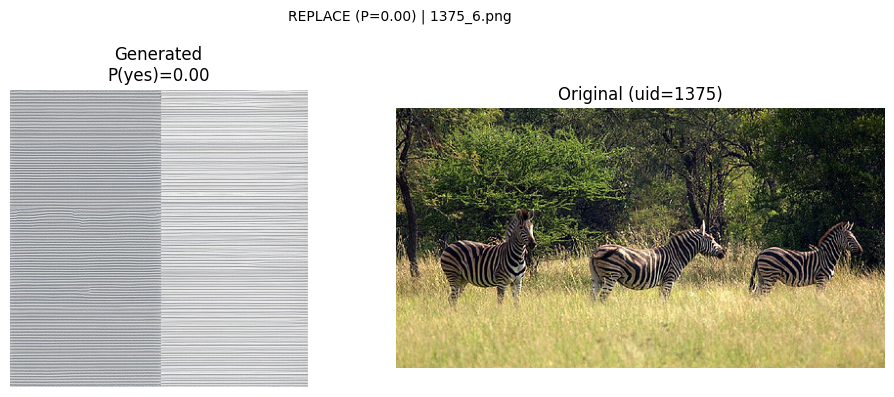

In [ ]:
# (5) Process each row: verify generated image, replace if bad
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

results = []
replaced_count = 0
missing_gen = 0
unkeep_count = 0  # Track total unkeeps (replaced + missing)
plot_every_unkeep = 5  # Show image every N unkeeps

for i, (idx, row) in enumerate(r_gen_df.iterrows()):
    uid = str(row["uid"])
    gen_image_path = row["image_path"]
    rationale = row["rationale"]
    orig_image_path = uid_to_original_image.get(uid, None)
    
    # Check if generated image exists
    if not os.path.exists(gen_image_path):
        missing_gen += 1
        unkeep_count += 1
        final_image_path = orig_image_path or gen_image_path
        p_yes = None
        use_original = True
        status = "MISSING"
        is_unkeep = True
    else:
        # Verify with VQA
        p_yes = get_yes_prob(model, gen_image_path, rationale)
        
        if p_yes < 0.1:
            final_image_path = orig_image_path or gen_image_path
            use_original = True
            replaced_count += 1
            unkeep_count += 1
            status = f"REPLACE (P={p_yes:.2f})"
            is_unkeep = True
        else:
            final_image_path = gen_image_path
            use_original = False
            status = f"KEEP (P={p_yes:.2f})"
            is_unkeep = False
    
    results.append({
        "idx": idx,
        "uid": uid,
        "p_yes": p_yes,
        "use_original": use_original,
        "final_image_path": final_image_path,
    })
    
    # Print and plot every N unkeeps
    if is_unkeep and unkeep_count % plot_every_unkeep == 0:
        clear_output(wait=True)
        print(f"[{i+1}/{len(r_gen_df)}] uid={uid} | {status}")
        print(f"  Rationale: {rationale}")
        print(f"  Unkeeps: {unkeep_count} (Replaced: {replaced_count}, Missing: {missing_gen})")
        
        # Show images side by side
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        # Generated image
        p_str = f"{p_yes:.2f}" if p_yes is not None else "N/A"
        if os.path.exists(gen_image_path):
            axes[0].imshow(Image.open(gen_image_path))
            axes[0].set_title(f"Generated\nP(yes)={p_str}")
        else:
            axes[0].text(0.5, 0.5, "MISSING", ha='center', va='center', fontsize=20)
            axes[0].set_title("Generated (MISSING)")
        axes[0].axis("off")
        
        # Original image
        if orig_image_path and os.path.exists(orig_image_path):
            axes[1].imshow(Image.open(orig_image_path))
            axes[1].set_title(f"Original (uid={uid})")
        else:
            axes[1].text(0.5, 0.5, "NO ORIGINAL", ha='center', va='center', fontsize=20)
            axes[1].set_title("Original (NOT FOUND)")
        axes[1].axis("off")
        
        plt.suptitle(f"{status} | {gen_image_path.split('/')[-1]}", fontsize=10)
        plt.tight_layout()
        plt.show()
    
    # Clear CUDA cache periodically
    if i % 100 == 0 and torch.cuda.is_available():
        torch.cuda.empty_cache()

clear_output(wait=True)
print(f"\n{'='*50}")
print(f"Done! Processed {len(r_gen_df)} images")
print(f"Unkeeps: {unkeep_count} (Replaced: {replaced_count}, Missing: {missing_gen})")
print(f"Keep rate: {100*(len(r_gen_df)-unkeep_count)/len(r_gen_df):.1f}%")


In [ ]:
# (6) Create cleaned r_gen_df
results_df = pd.DataFrame(results)

# Update image_path in r_gen_df
r_gen_df_clean = r_gen_df.copy()
r_gen_df_clean["image_path"] = results_df["final_image_path"].values
r_gen_df_clean["p_yes"] = results_df["p_yes"].values
r_gen_df_clean["use_original"] = results_df["use_original"].values

# Show distribution
print(f"P(yes) distribution for verified images:")
print(results_df["p_yes"].dropna().describe())
print(f"\nUse original: {results_df['use_original'].sum()} / {len(results_df)}")


In [ ]:
# # (7) Save cleaned r_gen_df
# out_path = f"data/r_gen/qa_clean/{dataset_name}.parquet"
# os.makedirs(os.path.dirname(out_path), exist_ok=True)
# r_gen_df_clean.to_parquet(out_path, index=False)
# print(f"Saved cleaned r_gen_df to {out_path}")


In [ ]:
# (8) Visualize some replaced examples
import matplotlib.pyplot as plt

# Get rows where we replaced the image
replaced_idx = results_df[results_df["use_original"] & results_df["p_yes"].notna()].head(5)

fig, axes = plt.subplots(len(replaced_idx), 2, figsize=(10, 4*len(replaced_idx)))
if len(replaced_idx) == 1:
    axes = [axes]

for i, (_, res_row) in enumerate(replaced_idx.iterrows()):
    orig_row = r_gen_df.loc[res_row["idx"]]
    gen_path = orig_row["image_path"]
    orig_path = uid_to_original_image.get(res_row["uid"])
    
    # Generated image
    if os.path.exists(gen_path):
        axes[i][0].imshow(Image.open(gen_path))
    axes[i][0].set_title(f"Generated (P(yes)={res_row['p_yes']:.2f})\n{gen_path.split('/')[-1]}")
    axes[i][0].axis("off")
    
    # Original image
    if orig_path and os.path.exists(orig_path):
        axes[i][1].imshow(Image.open(orig_path))
    axes[i][1].set_title(f"Original (REPLACED)\nrationale: {orig_row['rationale'][:50]}...")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()
